In [65]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(devtools)
library(data.table)
library(ggplot2)
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
d <- fread('data/phenotypes/filtered_phenotypes_binary.tsv')

In [99]:
files <- list.files('data/prs/scores', full.names = TRUE, pattern = "pgs.txt.gz")[14:30]

In [100]:
l <- lapply(files, function(f) {
    phenotype <- gsub("_pgs.txt.gz","",basename(f))
    prs <- fread(f)
    colnames(prs) <- c('eid', 'prs')
    if (phenotype %in% colnames(d)){
        pheno <- d[,c('eid',phenotype), with = FALSE]
        colnames(pheno)[2] <- 'is_case'
        mrg <- merge(prs, pheno, all.x = TRUE)
        mrg <- mrg[!is.na(mrg$is_case),]
        mrg$phenotype <- phenotype
        return(mrg)
    }
})


In [101]:
final <- do.call(rbind, l)

In [102]:
df_mean <- final %>% group_by(phenotype, is_case) %>% summarise(median = median(prs))

`summarise()` has grouped output by 'phenotype'. You can override using the `.groups` argument.



In [103]:
 plt <- ggplot(final, aes(x=prs, fill=is_case)) +
    #geom_density() +
    geom_histogram(color = 'black') +
    labs(fill="Case") +
    xlab('Polygenic Risk Score') +
    ylab("Frequency") +
    geom_vline(data = df_mean, aes(xintercept=median, color = is_case), linetype = 'dashed') + 
    theme_bw() +
    facet_wrap(~phenotype)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



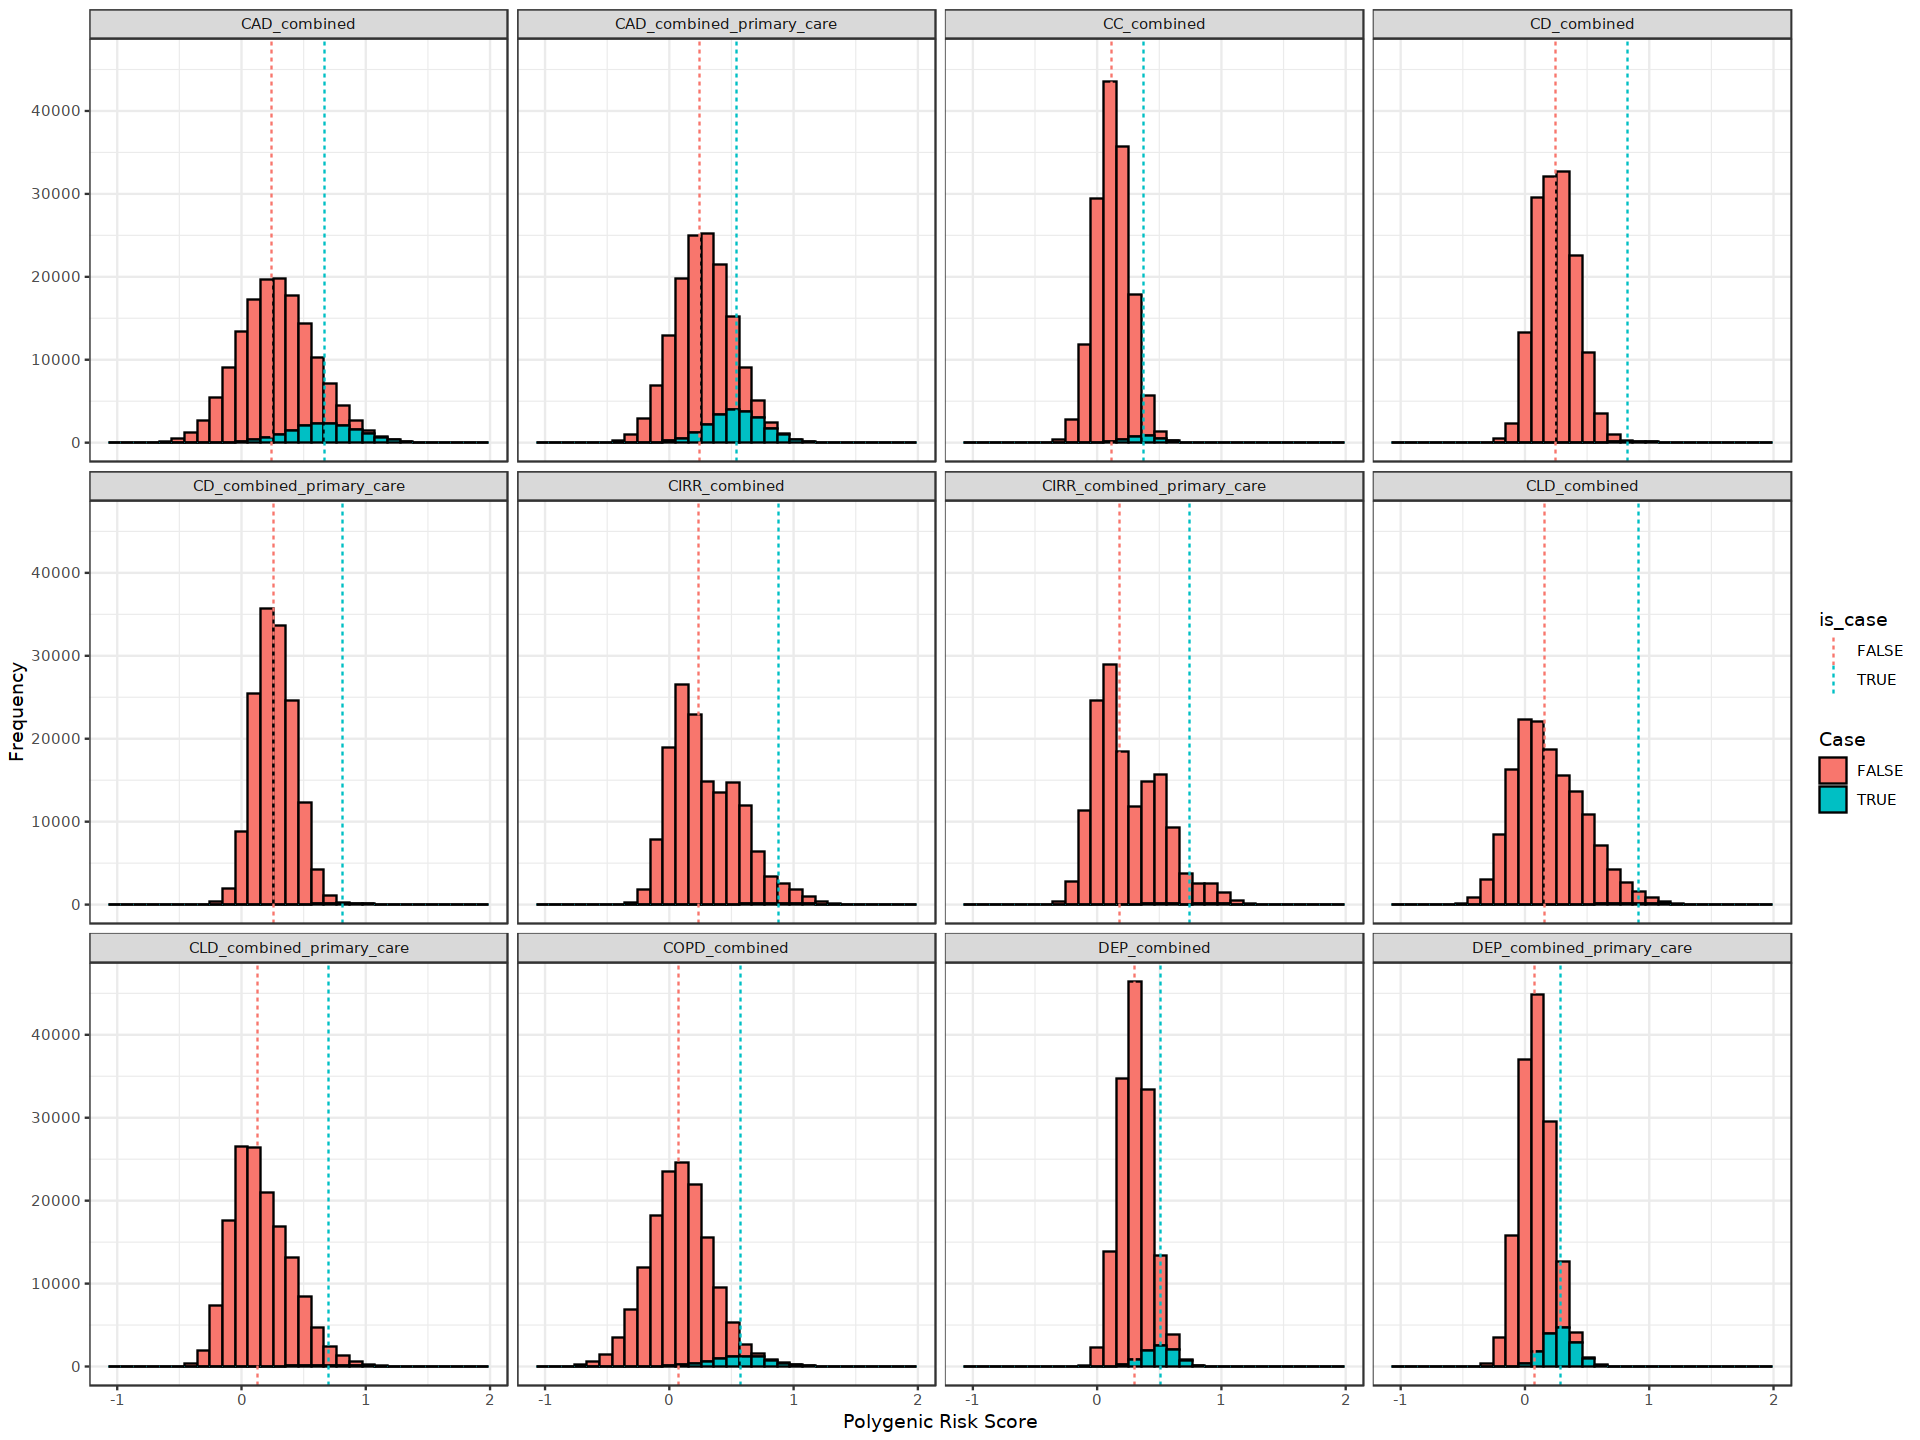

In [104]:
options(repr.plot.width=16, repr.plot.height=12)
print(plt)